In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Titanic-Dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
df.shape

(891, 12)

In [5]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
182,183,0,3,"Asplund, Master. Clarence Gustaf Hugo",male,9.0,4,2,347077,31.3875,NaN,S
289,290,1,3,"Connolly, Miss. Kate",female,22.0,0,0,370373,7.7500,NaN,Q
771,772,0,3,"Jensen, Mr. Niels Peder",male,48.0,0,0,350047,7.8542,NaN,S
325,326,1,1,"Young, Miss. Marie Grice",female,36.0,0,0,PC 17760,135.6333,C32,C
50,51,0,3,"Panula, Master. Juha Niilo",male,7.0,4,1,3101295,39.6875,NaN,S


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

Missing Value Analysis

In [4]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': (missing / len(df)) * 100
})

missing_df.sort_values('Percentage', ascending=False)

,Missing Values,Percentage
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
SibSp,0,0.000000
Parch,0,0.000000


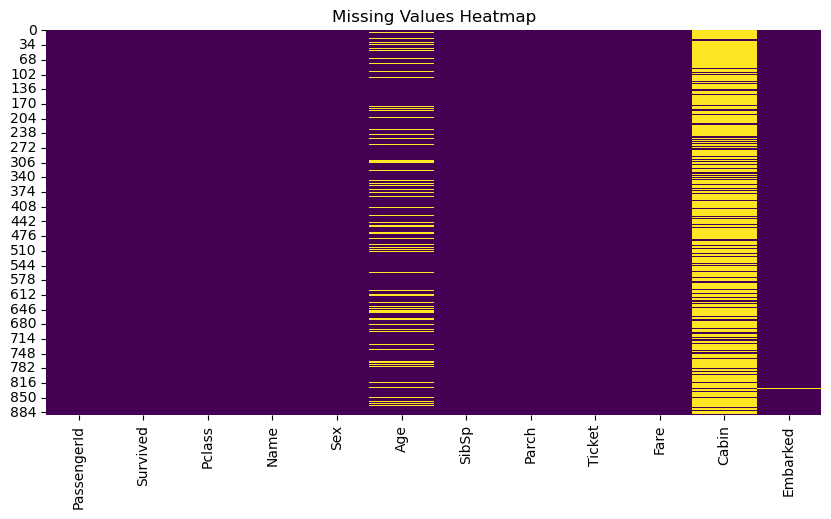

In [ ]:
#Missing values heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

 Numerical Variable Analysis

In [8]:
#First identify numerical columns.
num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

Descriptive Statistics

In [9]:
df[num_cols].describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
df[num_cols].agg(['mean', 'median', 'std', 'min', 'max','skew','kurt' ]).T

,mean,median,std,min,max,skew,kurt
PassengerId,446.000000,446.0000,257.353842,1.00,891.0000,0.000000,-1.200000
Survived,0.383838,0.0000,0.486592,0.00,1.0000,0.478523,-1.775005
Pclass,2.308642,3.0000,0.836071,1.00,3.0000,-0.630548,-1.280015
Age,29.699118,28.0000,14.526497,0.42,80.0000,0.389108,0.178274
SibSp,0.523008,0.0000,1.102743,0.00,8.0000,3.695352,17.880420
Parch,0.381594,0.0000,0.806057,0.00,6.0000,2.749117,9.778125
Fare,32.204208,14.4542,49.693429,0.00,512.3292,4.787317,33.398141


Distribution Analysis (Histogram)

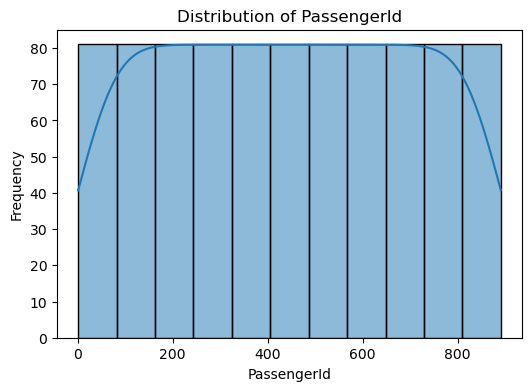

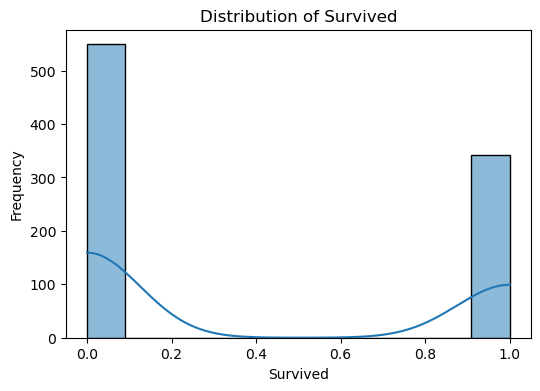

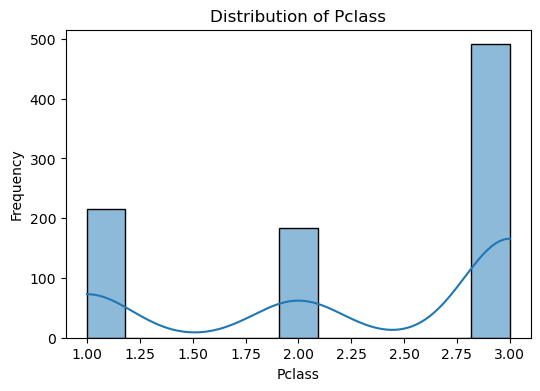

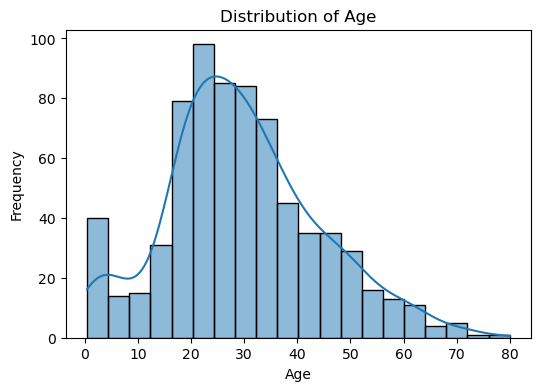

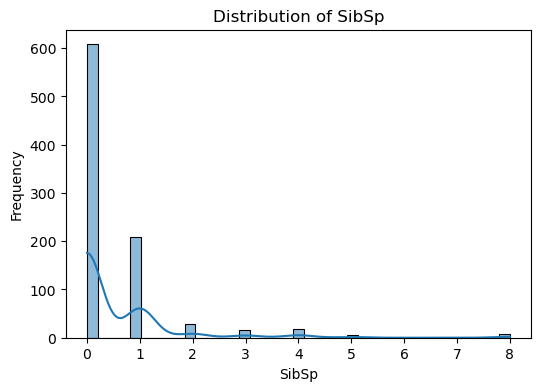

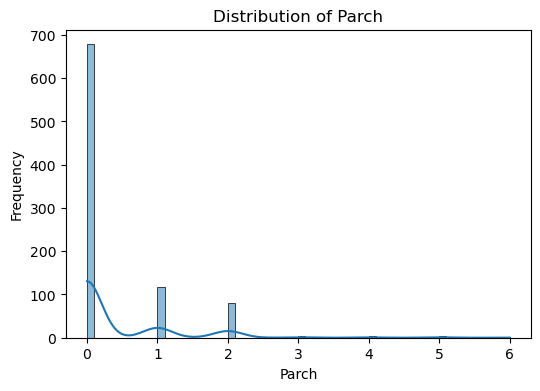

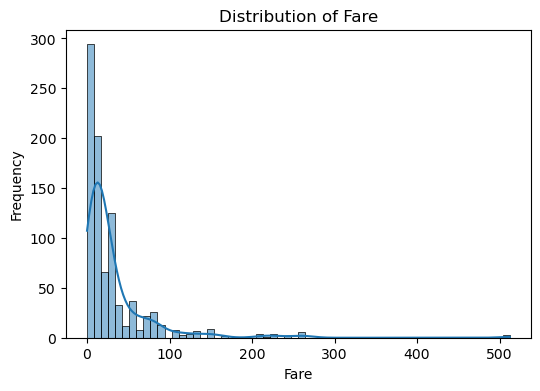

In [15]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

Density Plot

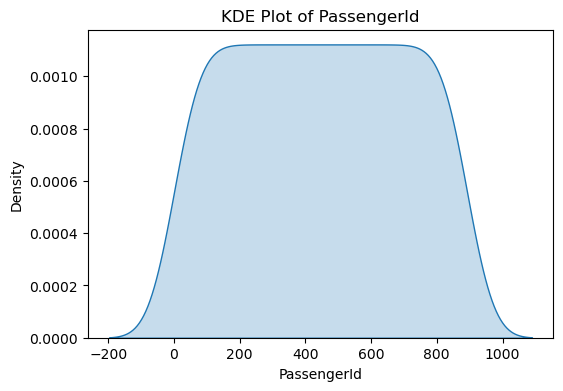

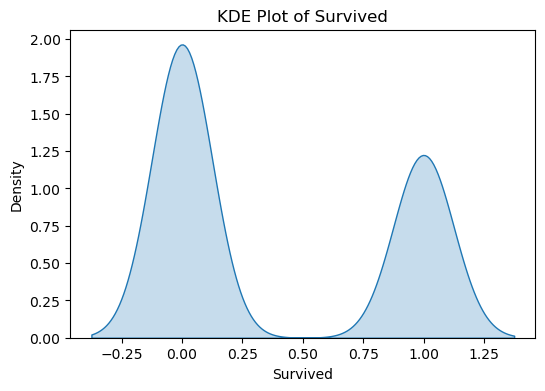

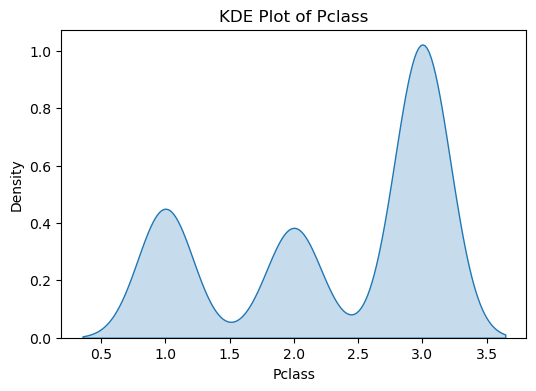

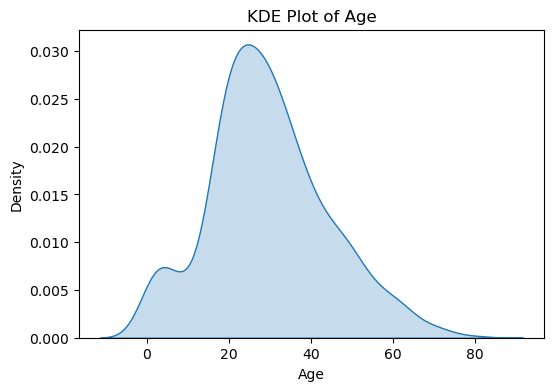

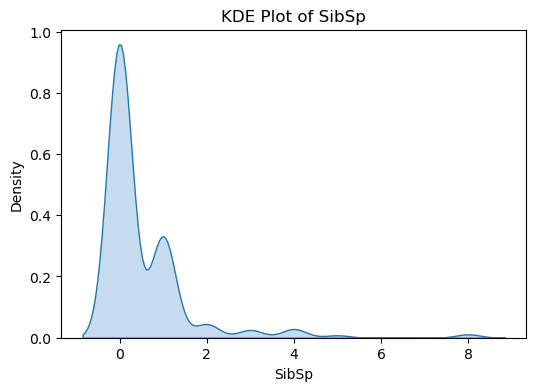

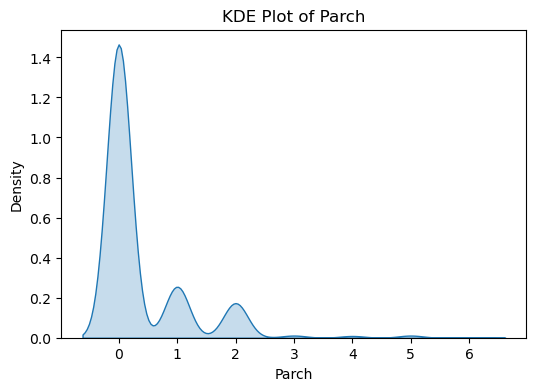

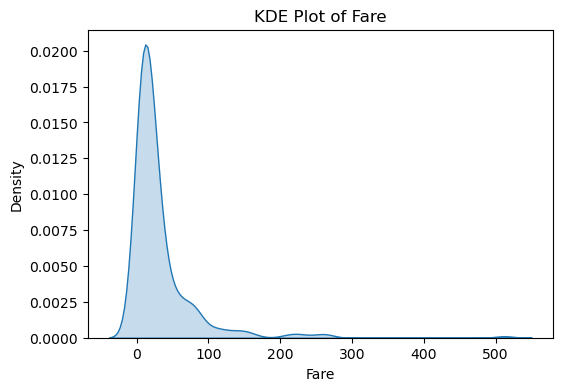

In [18]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(df[col], fill=True)
    plt.title(f'KDE Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.show()

Box Plot (Outlier Detection)

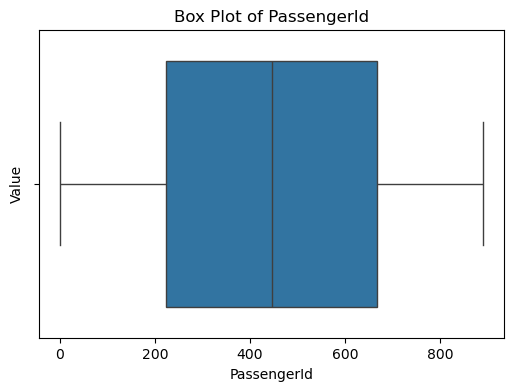

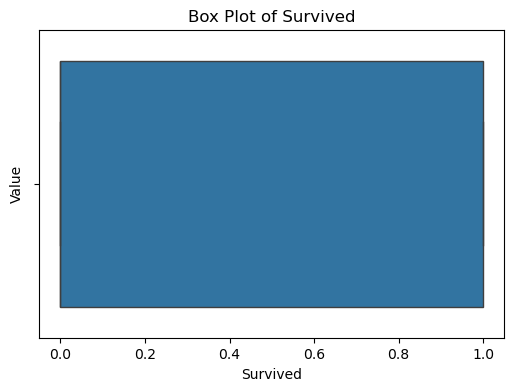

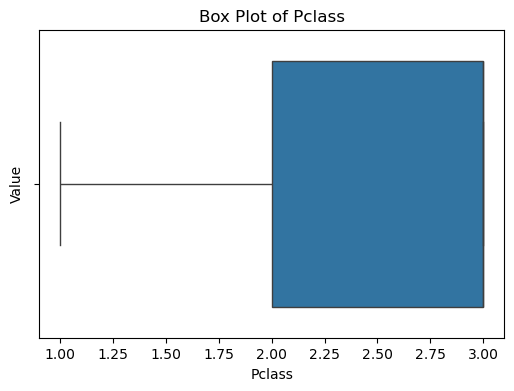

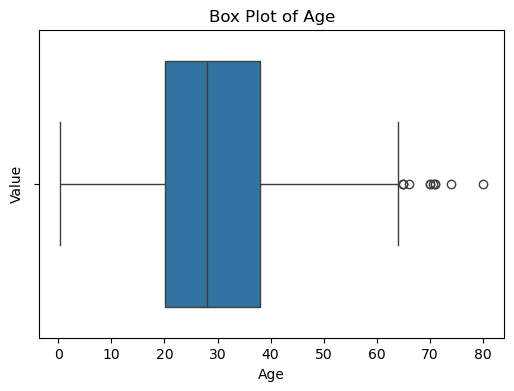

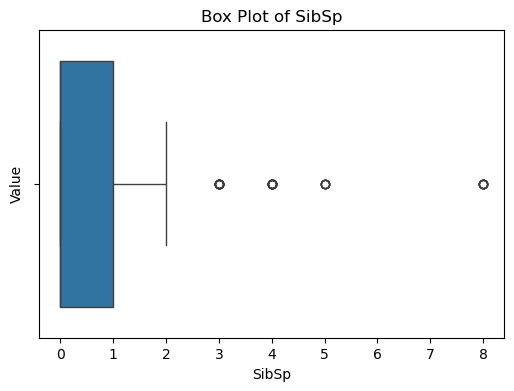

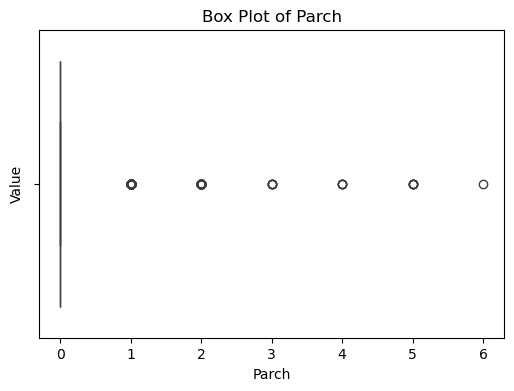

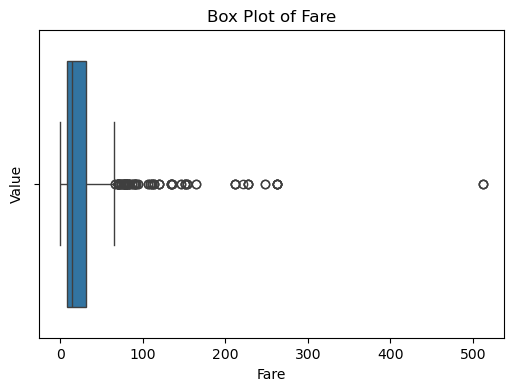

In [19]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Value')
    plt.show()

Skewness Analysis

In [20]:
for col in num_cols:
    print(f"{col}: {df[col].skew():.2f}")

PassengerId: 0.00
Survived: 0.48
Pclass: -0.63
Age: 0.39
SibSp: 3.70
Parch: 2.75
Fare: 4.79


Kurtosis Analysis


In [21]:
for col in num_cols:
    print(f"{col}: {df[col].kurt():.2f}")

PassengerId: -1.20
Survived: -1.78
Pclass: -1.28
Age: 0.18
SibSp: 17.88
Parch: 9.78
Fare: 33.40


Outlier Detection using IQR

In [22]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

PassengerId: 0 outliers
Survived: 0 outliers
Pclass: 0 outliers
Age: 11 outliers
SibSp: 46 outliers
Parch: 213 outliers
Fare: 116 outliers


Outlier Percentage

In [23]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    percentage = len(outliers)/len(df)*100

    print(col, round(percentage,2), "%")

PassengerId 0.0 %
Survived 0.0 %
Pclass 0.0 %
Age 1.23 %
SibSp 5.16 %
Parch 23.91 %
Fare 13.02 %


Automated Univariate Report

In [26]:
report = pd.DataFrame()

report['Column'] = df.columns
report['Dtype'] = df.dtypes.values
report['Missing'] = df.isnull().sum().values
report['Missing %'] = round(df.isnull().mean()*100,2).values
report['Unique'] = df.nunique().values

report

,Column,Dtype,Missing,Missing %,Unique
0,PassengerId,int64,0,0.00,891
1,Survived,int64,0,0.00,2
2,Pclass,int64,0,0.00,3
3,Name,object,0,0.00,891
4,Sex,object,0,0.00,2
5,Age,float64,177,19.87,88
6,SibSp,int64,0,0.00,7
7,Parch,int64,0,0.00,7
8,Ticket,object,0,0.00,681
9,Fare,float64,0,0.00,248
